<a href="https://colab.research.google.com/github/udlbook/udlbook/blob/main/Notebooks/Chap03/3_1_Shallow_Networks_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 3.1 -- Rede Neural Rasa I**

O objetivo deste notebook é ganhar alguma familiaridade com redes neurais rasas com entradas 1D. Funciona através de um exemplo semelhante à figura 3.3 e experimenta diferentes funções de ativação. <br>

Trabalhe nas células abaixo, executando cada célula por vez. Em vários lugares você verá as palavras “TO DO”. Siga as instruções nesses locais e escreva o código para completar as funções. Também há perguntas intercaladas no texto.

In [3]:
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt

Vamos primeiro construir a rede neural rasa com uma entrada, três unidades ocultas e uma saída descrita na seção 3.1 do livro

In [13]:
# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
    # ReLU: valores negativos viram 0, positivos permanecem iguais
    activation = preactivation.clip(min=0)
    return activation


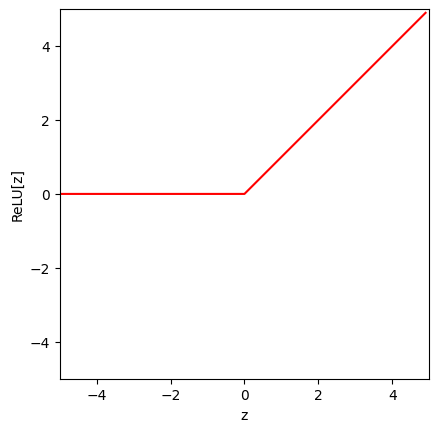

In [14]:
# Make an array of inputs
z = np.arange(-5,5,0.1)
RelU_z = ReLU(z)

# Plot the ReLU function
fig, ax = plt.subplots()
ax.plot(z,RelU_z,'r-')
ax.set_xlim([-5,5]);ax.set_ylim([-5,5])
ax.set_xlabel('z'); ax.set_ylabel('ReLU[z]')
ax.set_aspect('equal')
plt.show()

In [15]:
def shallow_1_1_3(x, activation_fn, phi_0, phi_1, phi_2, phi_3,
                  theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
    # Pre-activation values
    pre_1 = theta_10 + theta_11 * x
    pre_2 = theta_20 + theta_21 * x
    pre_3 = theta_30 + theta_31 * x

    # Activation values
    act_1 = activation_fn(pre_1)
    act_2 = activation_fn(pre_2)
    act_3 = activation_fn(pre_3)

    # Weight activations
    w_act_1 = phi_1 * act_1
    w_act_2 = phi_2 * act_2
    w_act_3 = phi_3 * act_3

    # Compute output
    y = phi_0 + w_act_1 + w_act_2 + w_act_3

    return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3


In [19]:
# Plot the shallow neural network.  We'll assume input in is range [0,1] and output [-1,1]
# If the plot_all flag is set to true, then we'll plot all the intermediate stages as in Figure 3.3
def plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=False, x_data=None, y_data=None):

  # Plot intermediate plots if flag set
  if plot_all:
    fig, ax = plt.subplots(3,3)
    fig.set_size_inches(8.5, 8.5)
    fig.tight_layout(pad=3.0)
    ax[0,0].plot(x,pre_1,'r-'); ax[0,0].set_ylabel('Preactivation')
    ax[0,1].plot(x,pre_2,'b-'); ax[0,1].set_ylabel('Preactivation')
    ax[0,2].plot(x,pre_3,'g-'); ax[0,2].set_ylabel('Preactivation')
    ax[1,0].plot(x,act_1,'r-'); ax[1,0].set_ylabel('Activation')
    ax[1,1].plot(x,act_2,'b-'); ax[1,1].set_ylabel('Activation')
    ax[1,2].plot(x,act_3,'g-'); ax[1,2].set_ylabel('Activation')
    ax[2,0].plot(x,w_act_1,'r-'); ax[2,0].set_ylabel('Weighted Act')
    ax[2,1].plot(x,w_act_2,'b-'); ax[2,1].set_ylabel('Weighted Act')
    ax[2,2].plot(x,w_act_3,'g-'); ax[2,2].set_ylabel('Weighted Act')

    for plot_y in range(3):
      for plot_x in range(3):
        ax[plot_y,plot_x].set_xlim([0,1]);ax[plot_x,plot_y].set_ylim([-1,1])
        ax[plot_y,plot_x].set_aspect(0.5)
      ax[2,plot_y].set_xlabel('Input, $x$');
    plt.show()

  fig, ax = plt.subplots()
  ax.plot(x,y)
  ax.set_xlabel('Input, $x$'); ax.set_ylabel('Output, $y$')
  ax.set_xlim([0,1]);ax.set_ylim([-1,1])
  ax.set_aspect(0.5)
  if x_data is not None:
    ax.plot(x_data, y_data, 'mo')
    for i in range(len(x_data)):
      ax.plot(x_data[i], y_data[i],)
  plt.show()

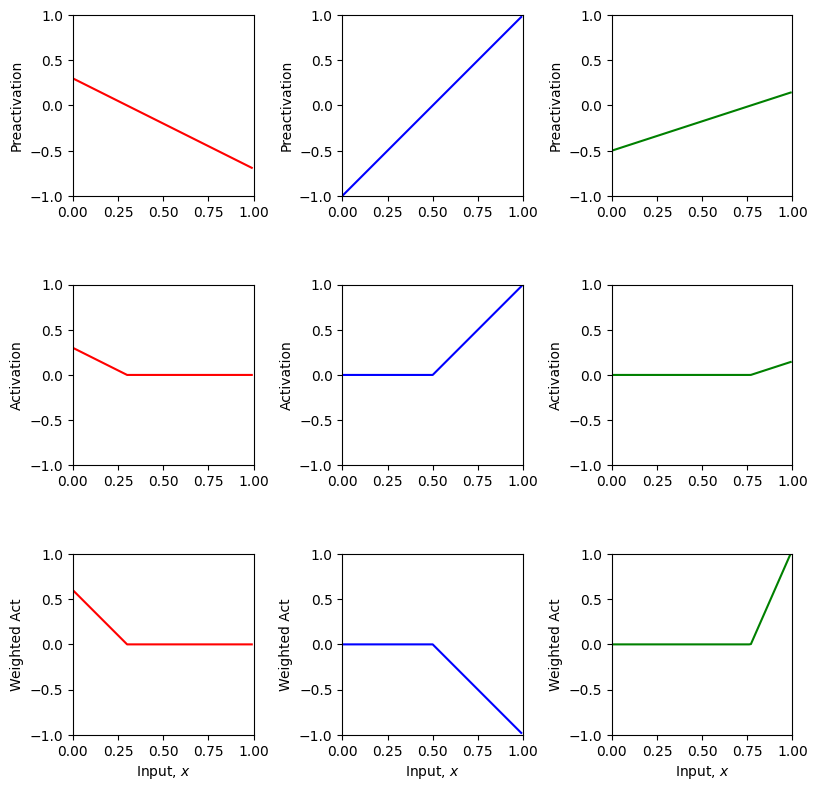

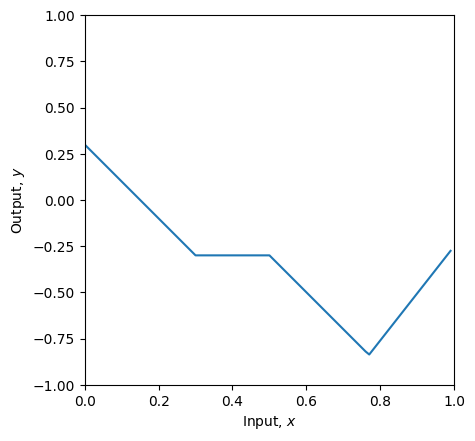

In [20]:
# Now lets define some parameters and run the neural network
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0  ; theta_21 = 2.0
theta_30 = -0.5  ; theta_31 = 0.65
phi_0 = -0.3; phi_1 = 2.0; phi_2 = -1.0; phi_3 = 7.0

# Define a range of input values
x = np.arange(0,1,0.01)

# We run the neural network for each of these input values
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# And then plot it
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)

If your code is correct, then the final output should look like this:


Now let's play with the parameters to make sure we understand how they work.  The original  parameters were:

$\theta_{10} =  0.3$ ; $\theta_{11} = -1.0$<br>
$\theta_{20} =  -1.0$ ; $\theta_{21} = 2.0$<br>
$\theta_{30} =  -0.5$ ; $\theta_{31} = 0.65$<br>
$\phi_0 = -0.3; \phi_1 = 2.0; \phi_2 = -1.0; \phi_3 = 7.0$

Base


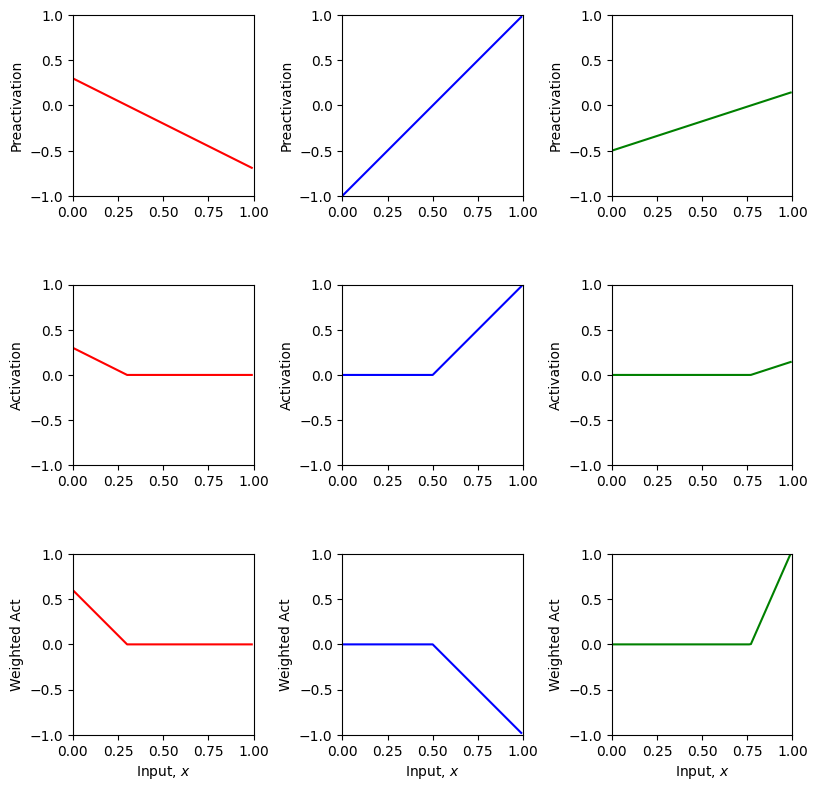

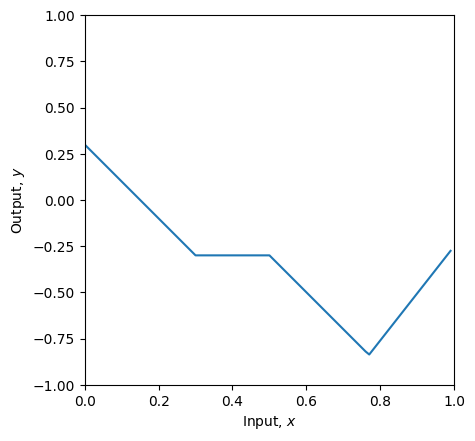

1) phi_0 + 0.5 (desloca para cima)


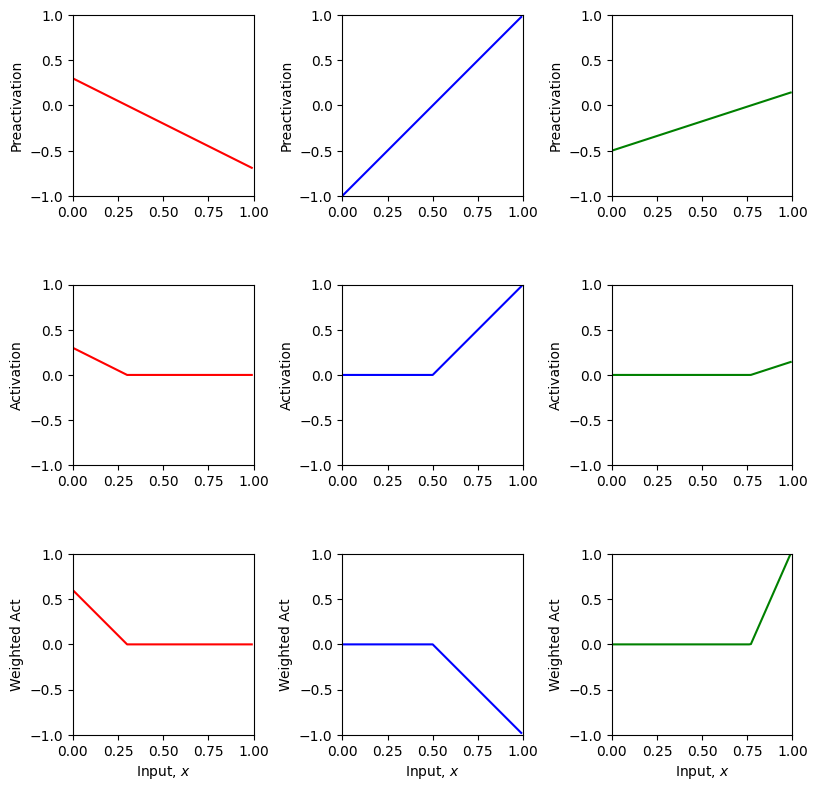

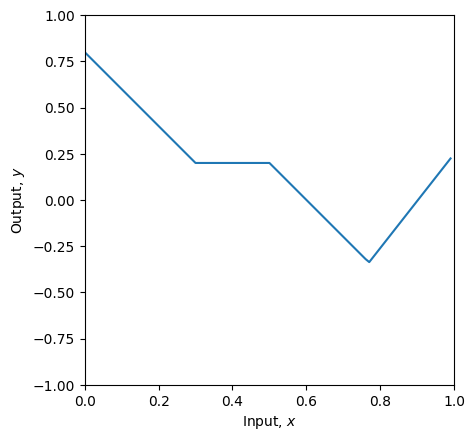

2) phi_1,phi_2,phi_3 * 0.5


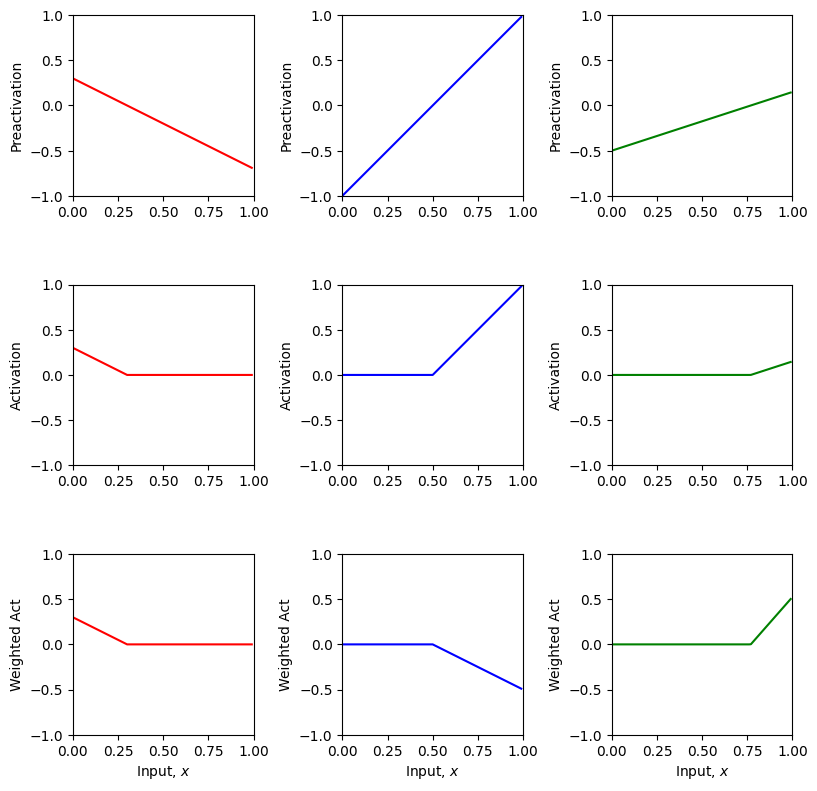

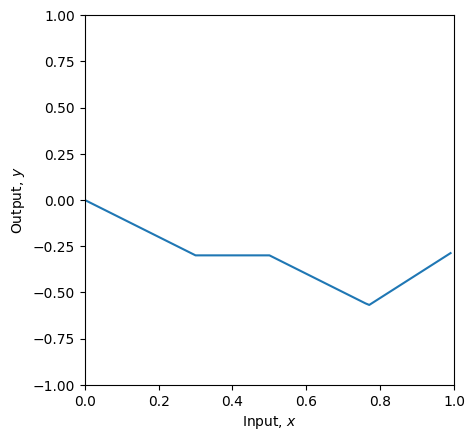

3) phi_1 * -1


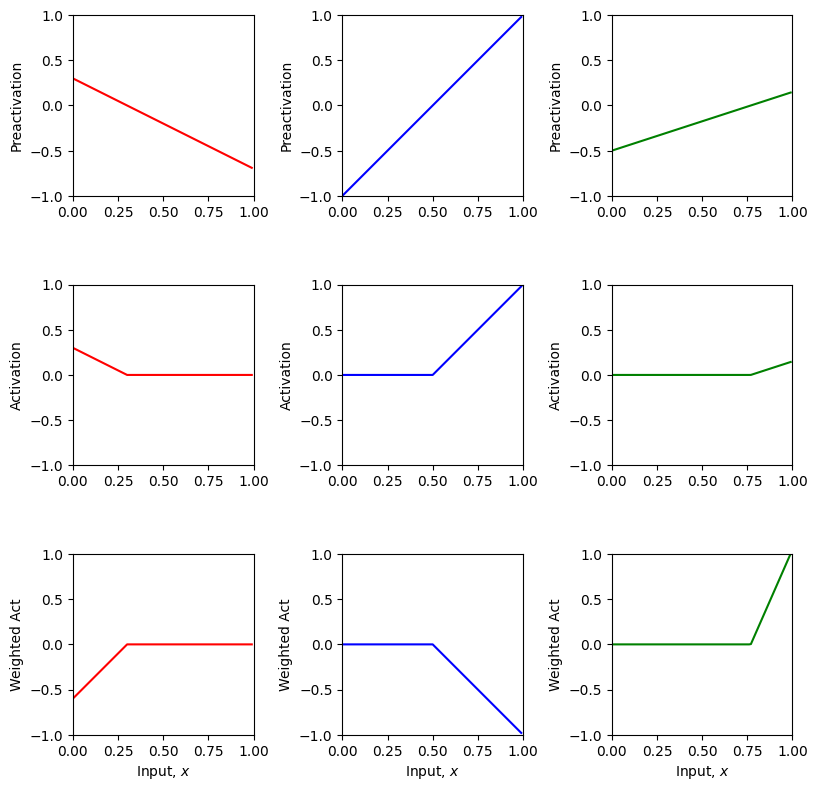

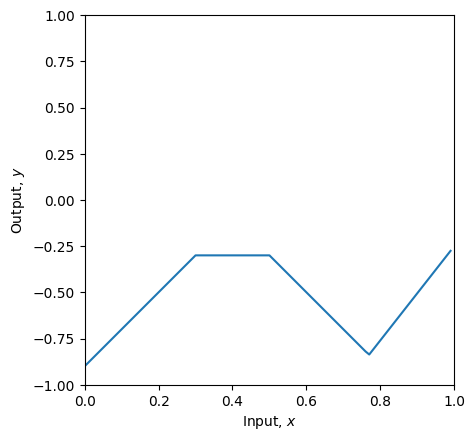

4) theta_20 = -1.2 (junta da unidade 2 em x=0.6)


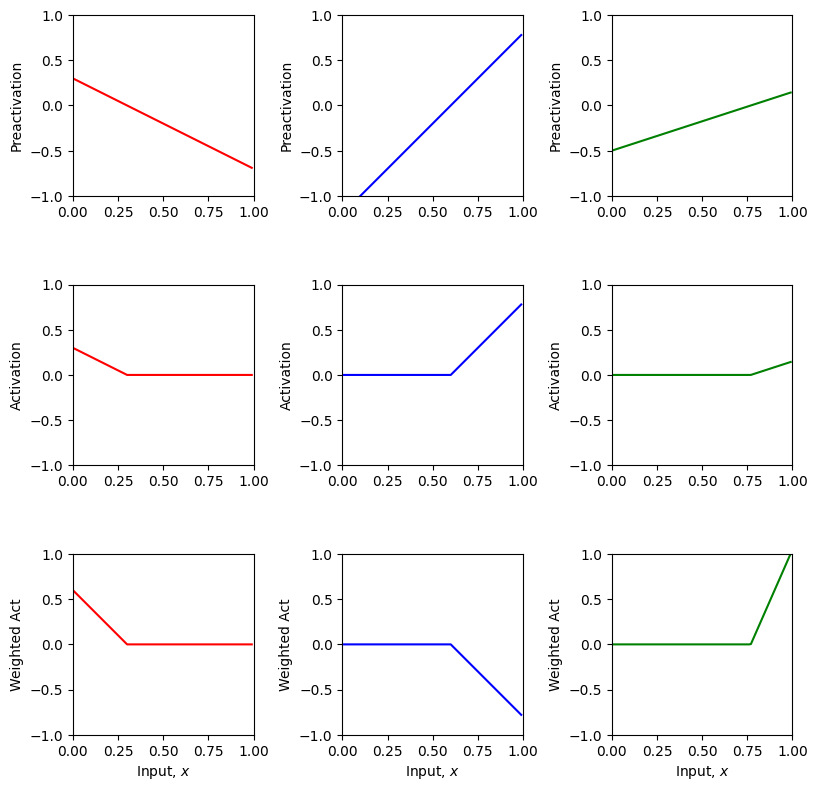

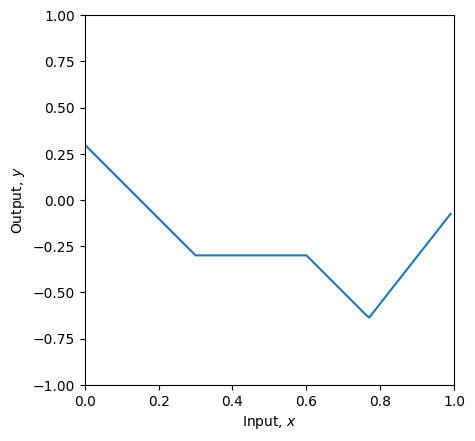

5a) duas juntas: phi_3 = 0


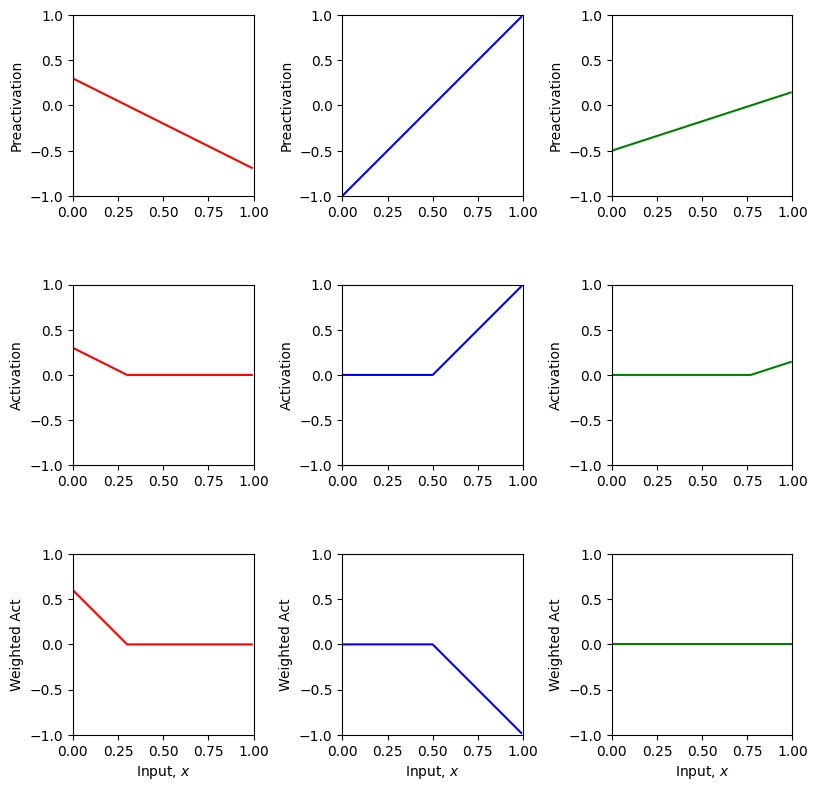

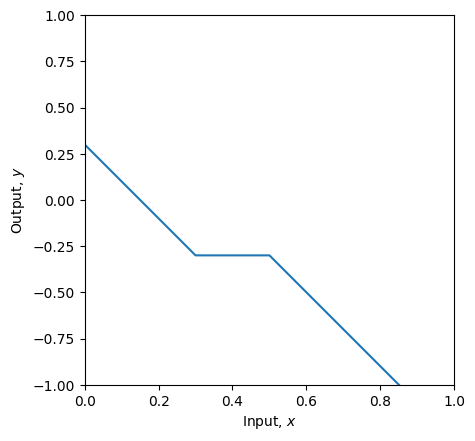

5b) duas juntas: junta da unidade 3 fora de [0,1]


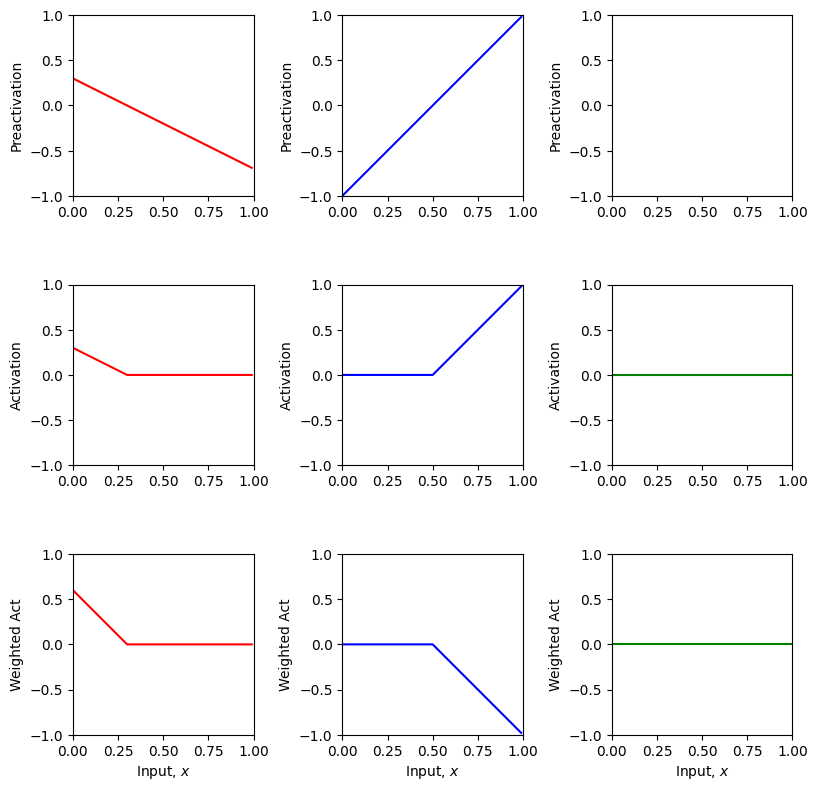

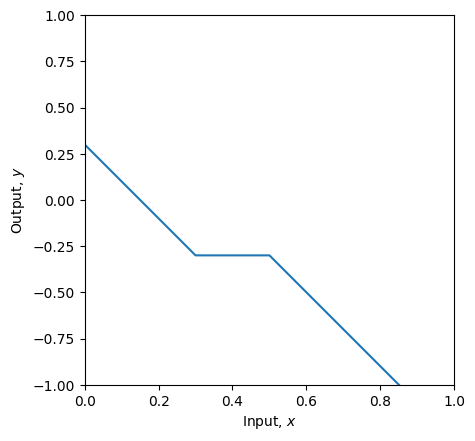

5c) duas juntas: juntas 1 e 2 coincidem em x=0.5


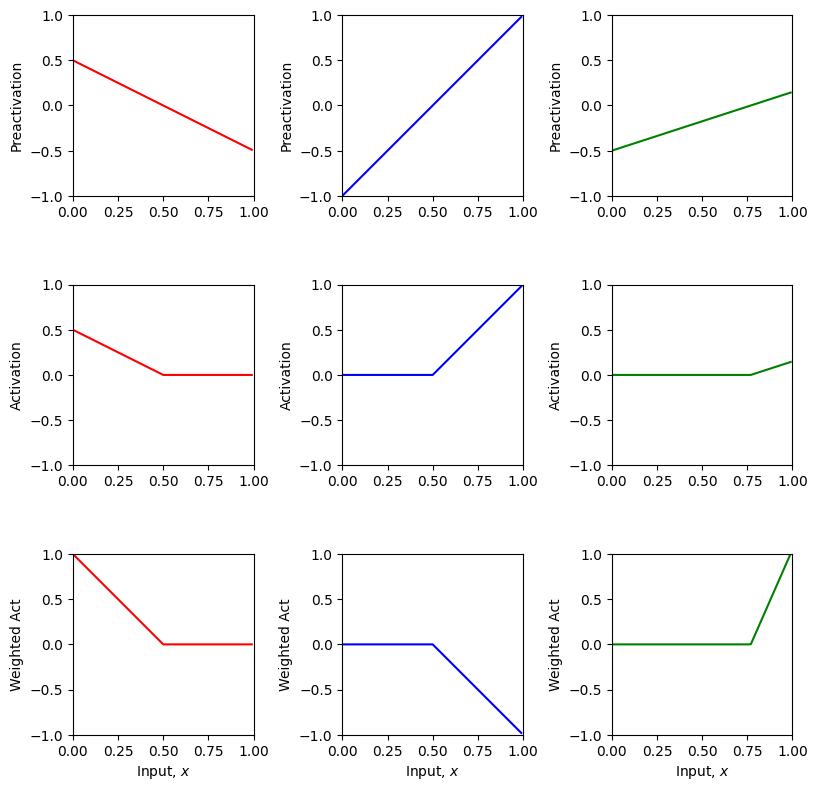

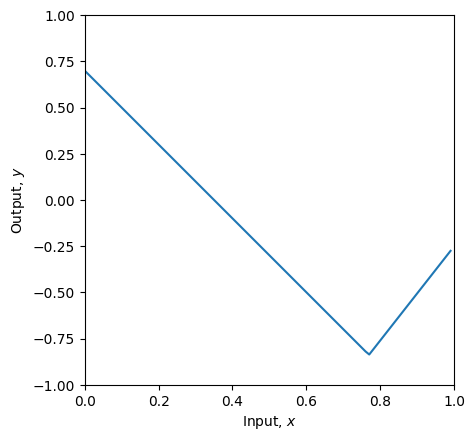

6) theta_10=0.8 (todos os segmentos com inclinacao nao nula)


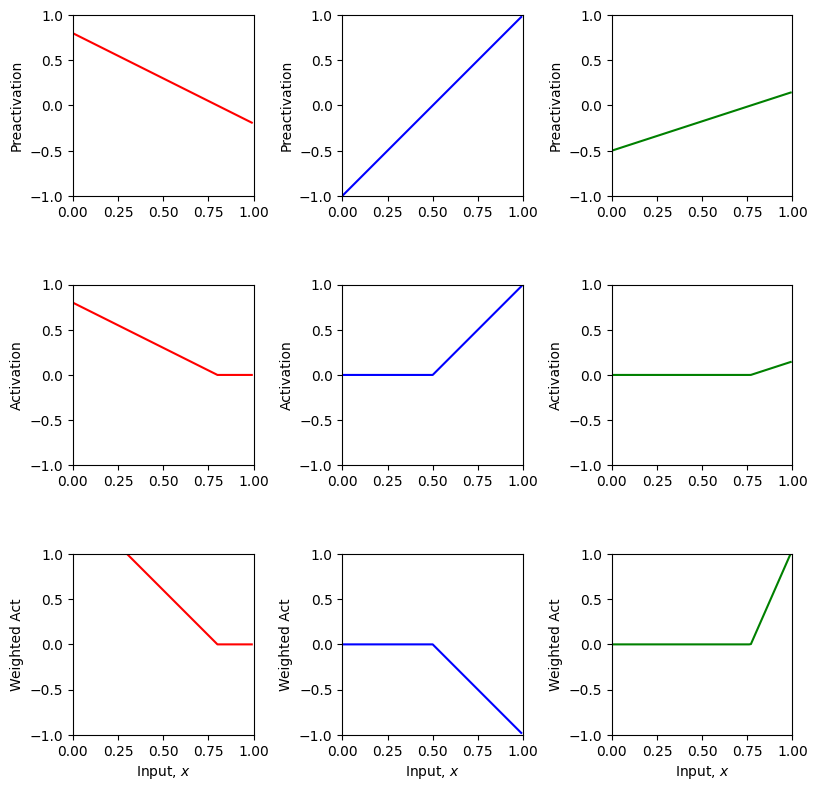

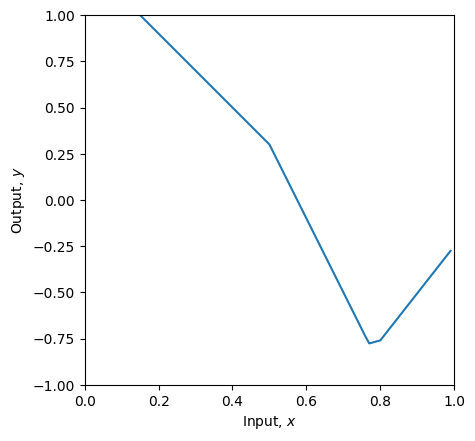

7) theta_20/theta_21 * 0.5 e phi_2 * 2.0 (saida da unidade 2 preservada)


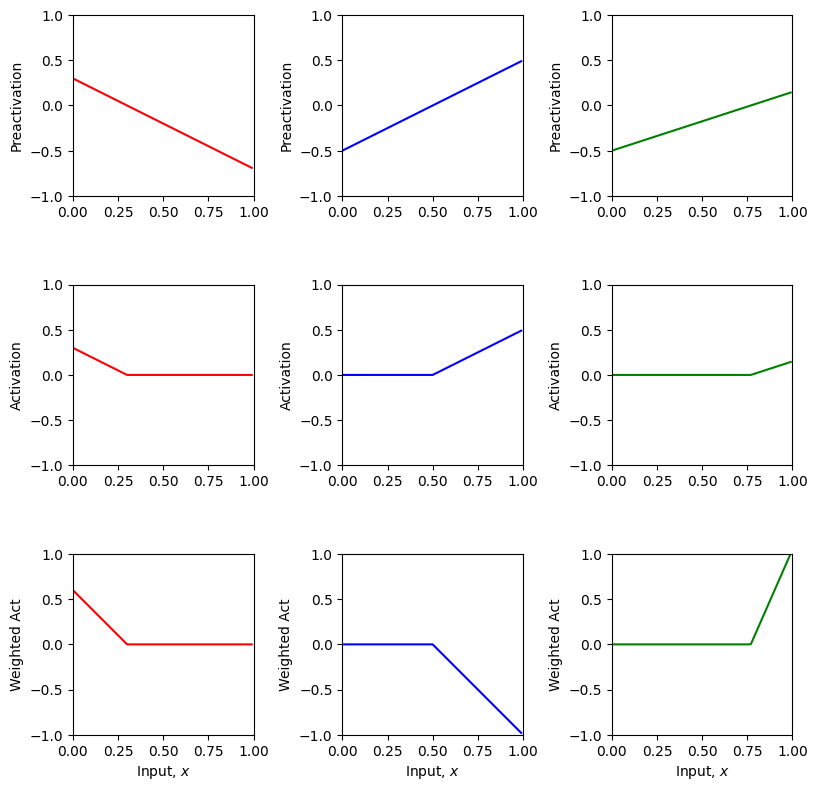

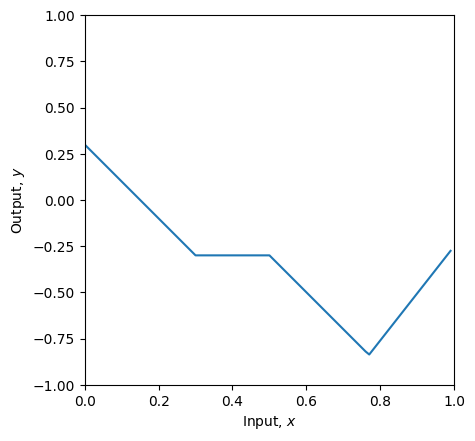

8) theta_20/theta_21 * -0.5 e phi_2 * -2.0 (lado ativo da unidade 2 inverte)


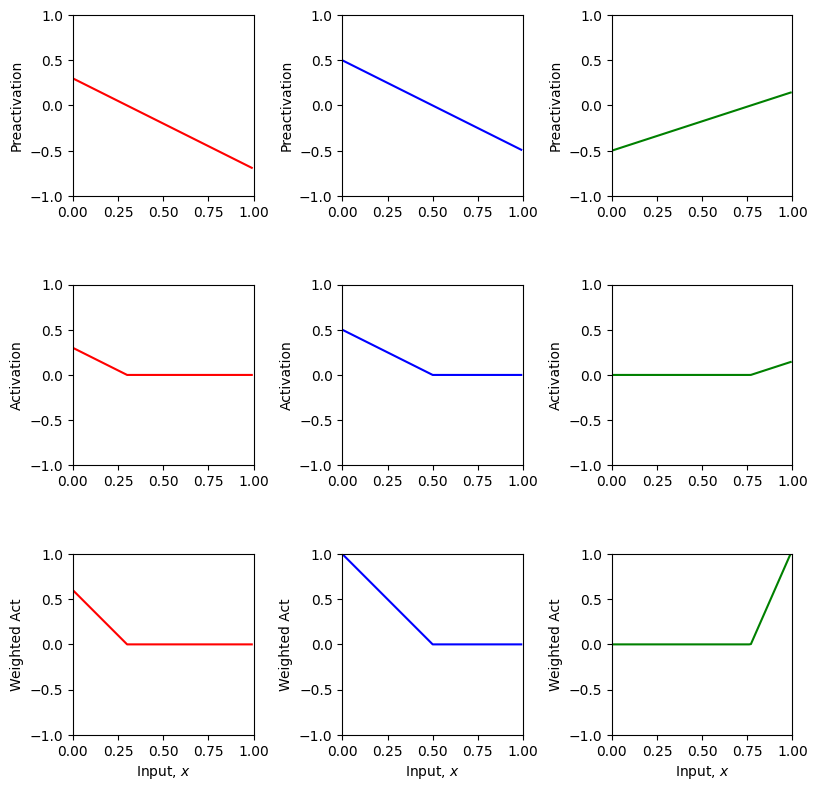

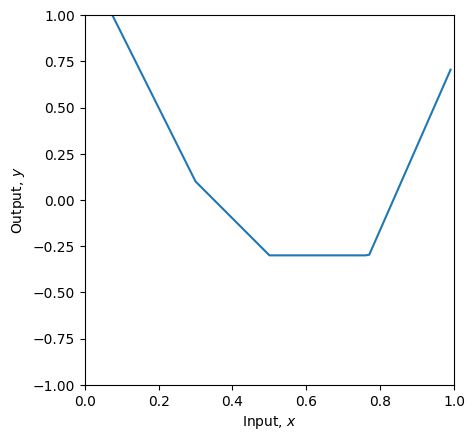

In [22]:
# TODO
# 1. Preveja o efeito que a alteração de phi_0 terá na rede.
# Resposta: phi_0 desloca toda a curva para cima/baixo sem mudar as "juntas" nem inclinações.

# 2. Preveja o efeito que a multiplicação de phi_1, phi_2, phi_3 por 0,5 teria.  Verifique se você está correto
# Resposta: reduz pela metade a contribuição das unidades ocultas (inclinações/curvaturas), mantendo as juntas nos mesmos x.

# 3. Preveja o efeito que a multiplicação de phi_1 por -1 terá.  Verifique se você está correto.
# Resposta: inverte o sinal da contribuição da 1a unidade (o trecho associado "espelha" verticalmente).

# 4. Preveja qual será o efeito de definir theta_20 como -1,2.  Verifique se você está correto.
# Resposta: desloca a junta da 2a unidade para a direita (x* = -theta_20/theta_21 passa de 0.5 para 0.6).

# 5. Altere os parâmetros de modo que haja apenas duas "juntas" (inclusive fora do intervalo do gráfico)
# Na verdade, há três maneiras de fazer isso. Veja se você consegue descobrir todas elas
# Resposta (3 formas):
# (a) zerar uma unidade: phi_i = 0
# (b) mover a junta de uma unidade para fora de [0,1]
# (c) fazer duas juntas coincidirem no mesmo x

# 6. Com os parâmetros originais, o segundo segmento de linha é plano (ou seja, tem inclinação zero)
# Como você poderia alterar theta_10 para que todos os segmentos tenham inclinações diferentes de zero?
# Resposta: mover a junta da 1a unidade para depois de x=0.5 (ex.: theta_10=0.8), evitando o trecho sem unidades ativas.

# 7. O que você prevê que aconteceria se você multiplicasse theta_20 e theta21 por 0,5 e phi_2 por 2,0?
# Verifique se você está correto.
# Resposta: a saída final da 2a unidade fica igual (efeitos se cancelam), então y praticamente não muda.

# 8. O que você prevê que aconteceria se você multiplicasse theta_20 e theta21 por -0,5 e phi_2 por -2,0?
# Verifique se você está correto.
# Resposta: a junta continua em x=0.5, mas o lado ativo da 2a unidade inverte (efeito muda de lado), alterando y.

# Parametros originais
theta_10 =  0.3 ; theta_11 = -1.0
theta_20 = -1.0 ; theta_21 =  2.0
theta_30 = -0.5 ; theta_31 =  0.65
phi_0 = -0.3 ; phi_1 = 2.0 ; phi_2 = -1.0 ; phi_3 = 7.0

# Defina um intervalo de valores de entrada
x = np.arange(0, 1, 0.01)

def run_case(title, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31, phi_0, phi_1, phi_2, phi_3):
    y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
        shallow_1_1_3(x, ReLU, phi_0, phi_1, phi_2, phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
    print(title)
    plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True)

# Caso base
run_case("Base",
         theta_10, theta_11, theta_20, theta_21, theta_30, theta_31,
         phi_0, phi_1, phi_2, phi_3)

# 1) Alterar phi_0
run_case("1) phi_0 + 0.5 (desloca para cima)",
         theta_10, theta_11, theta_20, theta_21, theta_30, theta_31,
         phi_0 + 0.5, phi_1, phi_2, phi_3)

# 2) phi_1, phi_2, phi_3 * 0.5
run_case("2) phi_1,phi_2,phi_3 * 0.5",
         theta_10, theta_11, theta_20, theta_21, theta_30, theta_31,
         phi_0, 0.5*phi_1, 0.5*phi_2, 0.5*phi_3)

# 3) phi_1 * -1
run_case("3) phi_1 * -1",
         theta_10, theta_11, theta_20, theta_21, theta_30, theta_31,
         phi_0, -phi_1, phi_2, phi_3)

# 4) theta_20 = -1.2
run_case("4) theta_20 = -1.2 (junta da unidade 2 em x=0.6)",
         theta_10, theta_11, -1.2, theta_21, theta_30, theta_31,
         phi_0, phi_1, phi_2, phi_3)

# 5a) Duas juntas: zerar uma unidade (phi_3 = 0)
run_case("5a) duas juntas: phi_3 = 0",
         theta_10, theta_11, theta_20, theta_21, theta_30, theta_31,
         phi_0, phi_1, phi_2, 0.0)

# 5b) Duas juntas: jogar junta para fora do intervalo [0,1] (unidade 3)
# x*_3 = -theta_30/theta_31 = -(-2.0)/0.65 = 3.08 (>1)
run_case("5b) duas juntas: junta da unidade 3 fora de [0,1]",
         theta_10, theta_11, theta_20, theta_21, -2.0, theta_31,
         phi_0, phi_1, phi_2, phi_3)

# 5c) Duas juntas: coincidir juntas 1 e 2 em x=0.5 => para unidade 1, theta_10=0.5 (theta_11=-1)
run_case("5c) duas juntas: juntas 1 e 2 coincidem em x=0.5",
         0.5, theta_11, theta_20, theta_21, theta_30, theta_31,
         phi_0, phi_1, phi_2, phi_3)

# 6) Tornar todos os segmentos com inclinacao != 0 (exemplo: theta_10=0.8)
run_case("6) theta_10=0.8 (todos os segmentos com inclinacao nao nula)",
         0.8, theta_11, theta_20, theta_21, theta_30, theta_31,
         phi_0, phi_1, phi_2, phi_3)

# 7) theta_20,theta_21 * 0.5 e phi_2 * 2.0
run_case("7) theta_20/theta_21 * 0.5 e phi_2 * 2.0 (saida da unidade 2 preservada)",
         theta_10, theta_11, 0.5*theta_20, 0.5*theta_21, theta_30, theta_31,
         phi_0, phi_1, 2.0*phi_2, phi_3)

# 8) theta_20,theta_21 * -0.5 e phi_2 * -2.0
run_case("8) theta_20/theta_21 * -0.5 e phi_2 * -2.0 (lado ativo da unidade 2 inverte)",
         theta_10, theta_11, -0.5*theta_20, -0.5*theta_21, theta_30, theta_31,
         phi_0, phi_1, -2.0*phi_2, phi_3)


# Least squares loss

Agora vamos considerar o ajuste da rede aos dados.  Primeiro, precisamos definir a função de perda.  Usaremos a perda dos mínimos quadrados:

\begin{equation}
L[\boldsymbol\phi] = \sum_{i=1}^{I}(y_{i}-\text{f}[x_{i},\boldsymbol\phi])^2
\end{equation}

one $(x_i,y_i)$ é um par de treinamento de entrada/saída e $\text{f}[\bullet,\boldsymbol\phi]$ é a rede com parâmetros $\boldsymbol\phi$.  O primeiro termo entre parênteses é a saída da verdade terrestre e o segundo termo é a previsão do modelo

In [24]:
def least_squares_loss(y_train, y_predict):
  loss = np.sum((y_train - y_predict)**2)
  return loss

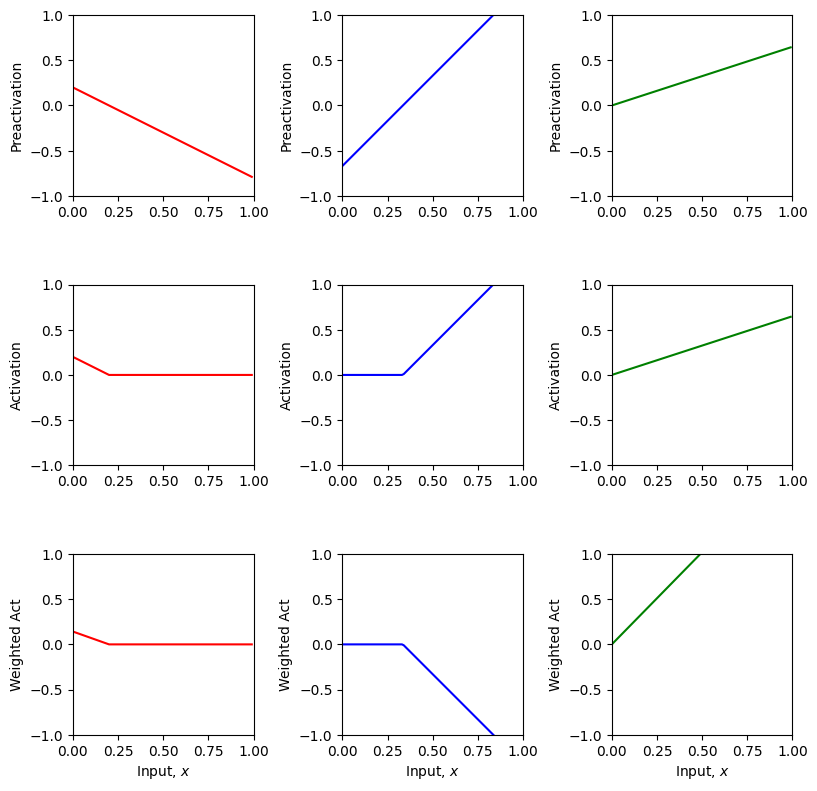

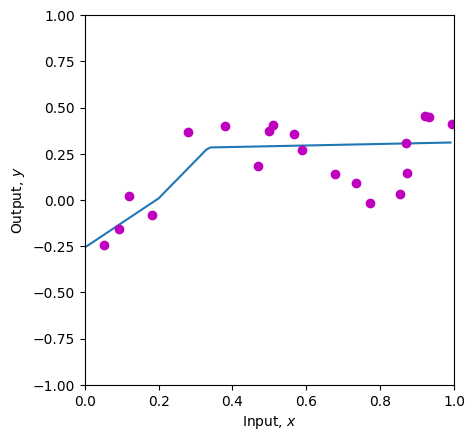

Your Loss = 0.434, True value = 9.385


In [25]:
# Now lets define some parameters, run the neural network, and compute the loss
theta_10 = 0.20  ; theta_11 = -1.0
theta_20 = -0.67 ; theta_21 = 2.0
theta_30 = 0.00  ; theta_31 = 0.65
phi_0 = -0.40 ; phi_1 = 0.71 ; phi_2 = -1.00 ; phi_3 = 3.14

#mudanca de paramtros

# Define a range of input values
x = np.arange(0,1,0.01)

x_train = np.array([0.09291784,0.46809093,0.93089486,0.67612654,0.73441752,0.86847339,\
                   0.49873225,0.51083168,0.18343972,0.99380898,0.27840809,0.38028817,\
                   0.12055708,0.56715537,0.92005746,0.77072270,0.85278176,0.05315950,\
                   0.87168699,0.58858043])
y_train = np.array([-0.15934537,0.18195445,0.451270150,0.13921448,0.09366691,0.30567674,\
                    0.372291170,0.40716968,-0.08131792,0.41187806,0.36943738,0.3994327,\
                    0.019062570,0.35820410,0.452564960,-0.0183121,0.02957665,-0.24354444, \
                    0.148038840,0.26824970])

# We run the neural network for each of these input values
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_1_1_3(x, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)
# And then plot it
plot_neural(x, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3, plot_all=True, x_data = x_train, y_data = y_train)

# Run the neural network on the training data
y_predict, *_ = shallow_1_1_3(x_train, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31)

# Compute the least squares loss and print it out
loss = least_squares_loss(y_train,y_predict)
print('Your Loss = %3.3f, True value = 9.385'%(loss))

# TODO.  Manipulate the parameters (by hand!) to make the function
# fit the data better and try to reduce the loss to as small a number
# as possible.  The best that I could do was 0.181
# Tip... start by manipulating phi_0.
# It's not that easy, so don't spend too much time on this!
